In [ ]:
# Installation
!pip install torch torchvision
!pip install opencv-python scikit-image matplotlib numpy Pillow
!pip install pycocotools

In [ ]:
import os
!git clone https://github.com/ia-project-parasite/IA-PROJECT-PARASITE-REPO.git
os.chdir('IA-PROJECT-PARASITE-REPO')

Cloning into 'IA-PROJECT-PARASITE-REPO'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 431 (delta 20), reused 77 (delta 16), pack-reused 345 (from 1)
Receiving objects: 100% (431/431), 730.61 MiB | 16.11 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (206/206), done.


In [ ]:
import os
import json
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign

from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects

import albumentations as A

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


# Dataset


**Image Enhancement** `apply_clahe_and_brightness(bgr)`

Enhances image visibility using a two-stage approach:
1. CLAHE applied to the luminance channel in LAB color space (preserves color fidelity)
2. Fixed brightness boost via HSV value channel

**Specimen Segmentation**

`specimen_mask(bgr, use_hull=False)`

Isolates the specimen from the background using adaptive thresholding on HSV channels. The algorithm:
- Computes Otsu's threshold on the value channel, scaled to 70% for robustness
- Applies morphological opening/closing to clean up noise
- Retains only the largest connected component
- Optionally returns convex hull for simplified boundary

`roi_from_mask(img, mask, pad=10)`

Extracts a bounding box around the masked region with optional padding. Returns cropped image and mask.


In [ ]:
def apply_clahe_and_brightness(bgr):
    """
    Apply contrast-limited adaptive histogram equalization (CLAHE)
    followed by a brightness boost to enhance image visibility.

    Args:
        bgr: Input image in BGR color space

    Returns:
        Enhanced BGR image with improved contrast and brightness
    """
    # Convert to LAB color space to work on luminance channel
    img_lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)

    # Apply CLAHE to luminance channel only (preserves color information)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l2 = clahe.apply(l)

    # Merge enhanced luminance back with original color channels
    img_lab = cv2.merge((l2, a, b))
    bgr_corr = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)

    # Additional brightness boost via HSV value channel
    hsv = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, 15)  # Add fixed brightness offset (saturates at 255)
    hsv = cv2.merge([h, s, v])
    bgr_corr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return bgr_corr


def specimen_mask(bgr, use_hull=False):
    """
    Generate a binary mask isolating the specimen from background.
    Uses adaptive thresholding on value/saturation channels.

    Args:
        bgr: Input image in BGR color space
        use_hull: If True, return convex hull of specimen instead of actual boundary

    Returns:
        Boolean mask where True indicates specimen pixels
    """
    # Convert to HSV for better foreground/background separation
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # Use Otsu's method to find optimal threshold, then scale down for robustness
    ret, _ = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    v_thr, s_thr = int(max(ret * 0.7, 25)), 15  # Minimum thresholds to avoid noise

    # Mask pixels with sufficient brightness and saturation (excludes dark background)
    m = ((V >= v_thr) & (S >= s_thr)).astype(np.uint8)

    # Morphological cleanup to remove noise and fill small gaps
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)   # Remove small bright spots
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)  # Fill small holes

    # Remove small disconnected regions and fill remaining holes
    m = remove_small_objects(m.astype(bool), min_size=3000)
    m = remove_small_holes(m, area_threshold=50000).astype(np.uint8)

    # Keep only the largest connected component (assumes single specimen)
    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return np.zeros(m.shape, bool)  # No foreground found
    cnts = np.bincount(lab.ravel())[1:]  # Skip background (label 0)
    keep = 1 + np.argmax(cnts)
    m = (lab == keep).astype(np.uint8)

    # Optionally compute convex hull for a simpler boundary
    if use_hull:
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            hull = cv2.convexHull(np.vstack(contours))
            m_hull = np.zeros_like(m)
            cv2.drawContours(m_hull, [hull], -1, 1, -1)
            m = m_hull

    return m.astype(bool)


def roi_from_mask(img, mask, pad=10):
    """
    Extract the bounding box region of interest from a binary mask.

    Args:
        img: Source image to crop
        mask: Binary mask indicating region of interest
        pad: Padding in pixels around the bounding box

    Returns:
        Tuple of (bbox_coords, cropped_image, cropped_mask) or (None, None, None) if empty
    """
    # Find all True pixels in the mask
    ys, xs = np.where(mask)
    if len(ys) == 0 or len(xs) == 0:
        return None, None, None

    # Compute bounding box with padding, clipped to image bounds
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad)

    return (y0, y1, x0, x1), img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def get_white_points_from_label(label_img):
    """
    Extract coordinates of white (bright) pixels from a label/annotation image.
    Used to parse point annotations marking parasite locations.

    Args:
        label_img: Annotation image (grayscale or BGR) with white markers

    Returns:
        List of (x, y) tuples for each white pixel
    """
    # Convert to grayscale if needed
    if len(label_img.shape) == 3:
        gray = cv2.cvtColor(label_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = label_img

    # Threshold to isolate near-white pixels (annotation markers)
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(thresh > 0)

    if len(xs) == 0:
        return []

    # Return as (x, y) coordinate pairs
    points = [(int(x), int(y)) for x, y in zip(xs, ys)]
    return points


def extract_centroids_from_points(points, img_shape):
    """
    Convert a dense point cloud (e.g., from brush annotations) into
    distinct object centroids via connected component analysis.

    Args:
        points: List of (x, y) coordinates forming annotation blobs
        img_shape: Shape of the original image (for creating binary mask)

    Returns:
        List of (x, y) centroid coordinates, one per connected region
    """
    if len(points) == 0:
        return []

    # Reconstruct binary mask from point list
    binary_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for x, y in points:
        if 0 <= y < img_shape[0] and 0 <= x < img_shape[1]:
            binary_mask[y, x] = 255

    # Label connected components (each annotation blob becomes one region)
    labeled_mask, num_parasites = ndimage_label(binary_mask)

    # Compute centroid for each labeled region
    centroids = []
    for region_id in range(1, num_parasites + 1):
        ys, xs = np.where(labeled_mask == region_id)
        if len(ys) > 0:
            centroid_x = int(xs.mean())
            centroid_y = int(ys.mean())
            centroids.append((centroid_x, centroid_y))

    return centroids

The following functions handle tile generation with instance-level segmentation masks:

- `create_instance_mask_from_centroids_fixed`: Converts binary masks to instance masks by assigning unique IDs to each parasite blob. Uses nearby pixel search to handle centroid misalignment and prevents duplicate blob assignments.

- `get_instances_from_mask`: Extracts individual instance masks and bounding boxes from the instance segmentation.

- `split_images_fixed_grid`: Splits images into fixed 1024×1024 tiles, generating instance masks for parasite-containing tiles. Keeps both positive (with parasites) and negative (specimen without parasites) tiles.

- `process_image_complete`: Full preprocessing pipeline that applies CLAHE, extracts the specimen ROI, converts annotations to centroids, and generates tiles with instance masks.

In [ ]:
def create_instance_mask_from_centroids_fixed(tile_mask, points_local, search_radius=10):
    """
    Convert binary mask to instance mask using centroids with robust matching.

    Each parasite blob gets a unique instance ID based on centroid assignment.
    Handles cases where centroids don't land exactly on mask pixels by searching
    nearby pixels in expanding squares.

    Args:
        tile_mask: Binary mask (0=background, 255=parasite)
        points_local: List of (x, y) centroid coordinates in tile space
        search_radius: Maximum distance to search for nearby blob if centroid
                       doesn't land directly on mask (default: 10 pixels)

    Returns:
        instance_mask: Integer array where each parasite has unique ID (1, 2, 3, ...)
        stats: Dictionary with diagnostic information:
            - total_centroids: Number of input centroids
            - direct_hits: Centroids that landed directly on a blob
            - nearby_hits: Centroids that found a blob via nearby search
            - missed: Centroids that couldn't find any blob
            - duplicate_blob: Centroids that mapped to an already-assigned blob
    """
    # Initialize statistics for debugging
    stats = {
        'total_centroids': len(points_local),
        'direct_hits': 0,
        'nearby_hits': 0,
        'missed': 0,
        'duplicate_blob': 0
    }

    # Handle empty inputs
    if tile_mask is None or len(points_local) == 0:
        return None, stats

    # Binarize mask and label connected components
    binary_mask = (tile_mask > 0).astype(np.uint8)
    labeled_mask, num_objects = ndimage_label(binary_mask)

    # Initialize output instance mask (0 = background)
    instance_mask = np.zeros_like(labeled_mask, dtype=np.int32)

    # Track which blobs have been assigned to prevent duplicates
    used_blobs = set()
    instance_id = 1

    # Process each centroid
    for (x, y) in points_local:
        # Check bounds
        if not (0 <= y < labeled_mask.shape[0] and 0 <= x < labeled_mask.shape[1]):
            stats['missed'] += 1
            continue

        # First try: direct lookup at centroid position
        blob_id = labeled_mask[y, x]

        if blob_id > 0:
            # Centroid landed directly on a blob
            stats['direct_hits'] += 1
        else:
            # Centroid missed the mask - search nearby pixels
            # Uses expanding square search pattern for efficiency
            found = False
            for radius in range(1, search_radius + 1):
                # Search only the perimeter of each square (not interior)
                for dy in range(-radius, radius + 1):
                    for dx in range(-radius, radius + 1):
                        # Skip interior pixels (only check perimeter)
                        if abs(dy) != radius and abs(dx) != radius:
                            continue

                        ny, nx = y + dy, x + dx

                        # Check bounds
                        if 0 <= ny < labeled_mask.shape[0] and 0 <= nx < labeled_mask.shape[1]:
                            if labeled_mask[ny, nx] > 0:
                                blob_id = labeled_mask[ny, nx]
                                found = True
                                break
                    if found:
                        break
                if found:
                    stats['nearby_hits'] += 1
                    break

            # Centroid couldn't find any blob within search radius
            if not found:
                stats['missed'] += 1
                continue

        # Check if this blob was already assigned to another centroid
        if blob_id in used_blobs:
            stats['duplicate_blob'] += 1
            continue

        # Assign unique instance ID to all pixels of this blob
        instance_mask[labeled_mask == blob_id] = instance_id
        used_blobs.add(blob_id)
        instance_id += 1

    return instance_mask, stats


def get_instances_from_mask(instance_mask, min_area=5):
    """
    Extract individual instance masks and bounding boxes from instance segmentation.

    Args:
        instance_mask: Integer mask where each instance has unique ID
        min_area: Minimum pixel area to keep an instance (default: 5)

    Returns:
        masks: List of binary masks, one per instance
        boxes: List of bounding boxes [x_min, y_min, x_max, y_max]
    """
    if instance_mask is None:
        return [], []

    masks, boxes = [], []

    # Get all unique instance IDs (excluding background=0)
    unique_ids = np.unique(instance_mask)
    unique_ids = unique_ids[unique_ids > 0]

    for inst_id in unique_ids:
        # Extract binary mask for this instance
        mask = (instance_mask == inst_id).astype(np.uint8)
        area = mask.sum()

        # Filter out tiny instances (likely noise)
        if area < min_area:
            continue

        # Find bounding box
        pos = np.where(mask)
        if len(pos[0]) == 0:
            continue

        y_min, y_max = pos[0].min(), pos[0].max()
        x_min, x_max = pos[1].min(), pos[1].max()

        # Ensure non-degenerate boxes (at least 1 pixel wide/tall)
        if x_max <= x_min:
            x_max = x_min + 1
        if y_max <= y_min:
            y_max = y_min + 1

        masks.append(mask)
        boxes.append([x_min, y_min, x_max, y_max])

    return masks, boxes


def split_images_fixed_grid(original_img, label_img, mask_img, points, tile_size=1024):
    """
    Split images into fixed-size non-overlapping tiles with instance mask generation.

    Generates tiles from the image grid and creates instance masks for tiles
    containing parasites. Skips completely empty tiles (pure black background)
    but keeps both positive (with parasites) and negative (specimen without parasites) tiles.

    Args:
        original_img: Preprocessed RGB image (H, W, 3)
        label_img: Label image with parasite annotations
        mask_img: Binary segmentation mask (optional, can be None)
        points: List of (x, y) parasite centroid coordinates
        tile_size: Size of square tiles (default: 1024)

    Returns:
        tiles: List of tile dictionaries containing:
            - tile_original: Cropped/padded image tile
            - tile_label: Cropped/padded label tile
            - tile_mask: Cropped/padded binary mask (or None)
            - instance_mask: Integer mask with unique IDs per parasite (or None for negative tiles)
            - points_local: Centroid coordinates in tile space
            - tile_id: Unique tile identifier
            - global_bbox: (x1, y1, x2, y2) position in original image
            - num_parasites: Number of parasites in tile
            - is_negative: True if tile contains no parasites
        total_stats: Aggregated instance mask statistics across all tiles
    """
    height, width = original_img.shape[:2]
    tiles = []
    tile_count = 0

    # Aggregate statistics across all tiles
    total_stats = {'direct_hits': 0, 'nearby_hits': 0, 'missed': 0, 'duplicate_blob': 0}

    # Iterate over non-overlapping grid
    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            # Define tile boundaries
            x1, y1 = x, y
            x2, y2 = min(x + tile_size, width), min(y + tile_size, height)

            # Crop tiles from each image layer
            tile_original = original_img[y1:y2, x1:x2]
            tile_label = label_img[y1:y2, x1:x2]
            tile_mask = mask_img[y1:y2, x1:x2] if mask_img is not None else None

            # Handle edge tiles that need padding to reach tile_size
            actual_h, actual_w = tile_original.shape[:2]
            if actual_h < tile_size or actual_w < tile_size:
                # Pad original image
                padded_original = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                padded_original[:actual_h, :actual_w] = tile_original

                # Pad label (handle both grayscale and RGB)
                if len(tile_label.shape) == 3:
                    padded_label = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                else:
                    padded_label = np.zeros((tile_size, tile_size), dtype=np.uint8)
                padded_label[:actual_h, :actual_w] = tile_label

                # Pad mask if present
                padded_mask = None
                if tile_mask is not None:
                    padded_mask = np.zeros((tile_size, tile_size), dtype=np.uint8)
                    padded_mask[:actual_h, :actual_w] = tile_mask

                tile_original, tile_label, tile_mask = padded_original, padded_label, padded_mask

            # Skip completely empty tiles (pure black background)
            # Threshold of 5 allows for very dark but non-empty regions
            if tile_original.mean() < 5:
                continue

            # Find parasite centroids within this tile (convert to local coordinates)
            tile_points = [(px - x1, py - y1) for px, py in points if x1 <= px < x2 and y1 <= py < y2]

            # Generate instance mask only for tiles with parasites
            instance_mask = None
            if len(tile_points) > 0 and tile_mask is not None:
                instance_mask, stats = create_instance_mask_from_centroids_fixed(tile_mask, tile_points)
                # Accumulate statistics
                for key in total_stats:
                    total_stats[key] += stats.get(key, 0)

            # Store tile (both positive and negative tiles are kept)
            tiles.append({
                'tile_original': tile_original,
                'tile_label': tile_label,
                'tile_mask': tile_mask,
                'instance_mask': instance_mask,
                'points_local': tile_points,
                'tile_id': f"tile_{tile_count:04d}",
                'global_bbox': (x1, y1, x2, y2),
                'num_parasites': len(tile_points),
                'is_negative': len(tile_points) == 0
            })
            tile_count += 1

    return tiles, total_stats


def process_image_complete(image_path, label_path, mask_path, image_id,
                           tile_size=1024, apply_clahe=True, extract_roi=True):
    """
    Complete preprocessing pipeline for a single specimen image.

    Performs the full workflow:
        1. Load images (original, label, mask)
        2. Apply CLAHE contrast enhancement
        3. Extract specimen ROI and mask background
        4. Extract parasite centroids from label annotations
        5. Split into fixed-size tiles with instance masks

    Args:
        image_path: Path to raw specimen image
        label_path: Path to label image with white point annotations
        mask_path: Path to binary segmentation mask (optional)
        image_id: Unique identifier for this image
        tile_size: Size of output tiles (default: 1024)
        apply_clahe: Apply CLAHE preprocessing (default: True)
        extract_roi: Extract specimen ROI and mask background (default: True)

    Returns:
        tiles: List of tile dictionaries with instance masks and metadata
        stats: Instance mask generation statistics
    """
    # Load images
    img = cv2.imread(image_path)
    label = cv2.imread(label_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path and os.path.exists(mask_path) else None

    if img is None or label is None:
        print(f"Warning: Could not read {image_id}")
        return [], {}

    original_shape = img.shape

    # Apply contrast enhancement
    if apply_clahe:
        img = apply_clahe_and_brightness(img)

    # Extract region of interest (specimen only)
    roi_bbox = None
    if extract_roi:
        specimen_m = specimen_mask(img, use_hull=False)
        bbox, img_roi, mask_roi = roi_from_mask(img, specimen_m, pad=10)

        if bbox is None:
            # Fallback: use entire image
            img_roi, label_roi, mask_roi_img = img, label, mask
        else:
            y0, y1, x0, x1 = bbox
            roi_bbox = bbox

            # Black out background outside specimen
            img_roi = img_roi.copy()
            img_roi[~mask_roi] = 0

            # Crop label and mask to ROI
            label_roi = label[y0:y1, x0:x1]
            mask_roi_img = mask[y0:y1, x0:x1] if mask is not None else None
    else:
        img_roi, label_roi, mask_roi_img = img, label, mask

    # Extract white pixels from label annotations
    points = get_white_points_from_label(label_roi)
    if len(points) == 0:
        return [], {}

    # Convert dense point annotations to centroids
    centroids = extract_centroids_from_points(points, label_roi.shape)
    print(f"  [{image_id}] {len(points)} pixels -> {len(centroids)} centroids")

    if len(centroids) == 0:
        return [], {}

    # Split into tiles with instance mask generation
    tiles, stats = split_images_fixed_grid(img_roi, label_roi, mask_roi_img, centroids, tile_size=tile_size)

    # Add metadata to each tile
    for tile in tiles:
        tile['image_id'] = f"{image_id}_{tile['tile_id']}"
        tile['base_image_id'] = image_id
        tile['original_shape'] = original_shape
        tile['roi_bbox'] = roi_bbox

    return tiles, stats

In [ ]:
museum_labels_dir = "Museum labels"
output_dir = "Combined_Dataset"
TILE_SIZE = 1024

os.makedirs(output_dir, exist_ok=True)

# Find all folders
folders = [f for f in os.listdir(museum_labels_dir)
           if os.path.isdir(os.path.join(museum_labels_dir, f))]

all_tiles = []
tiles_per_image = {}

# Process each image
for folder in tqdm(folders, desc="Processing images"):
    folder_path = os.path.join(museum_labels_dir, folder)

    # Look for files
    raw_img_path = os.path.join(folder_path, f"{folder}.JPG")
    label_mask_path = os.path.join(folder_path, f"{folder}_labels.png")
    mask_path = os.path.join(folder_path, f"{folder}_mask.png")  # Ground truth mask

    if not os.path.exists(label_mask_path):
        label_mask_path = os.path.join(folder_path, f"{folder}_labels.JPG")

    if not os.path.exists(raw_img_path) or not os.path.exists(label_mask_path):
        continue

    # Process with complete pipeline
    tiles = process_image_complete(
        raw_img_path,
        label_mask_path,
        mask_path if os.path.exists(mask_path) else None,
        folder,
        tile_size=TILE_SIZE,
        apply_clahe=True,
        extract_roi=True
    )

    if len(tiles) == 0:
        continue

    # Create folder structure
    image_output_dir = os.path.join(output_dir, folder)
    tiles_dir = os.path.join(image_output_dir, "tiles")
    labels_dir = os.path.join(image_output_dir, "labels")
    masks_dir = os.path.join(image_output_dir, "masks")
    annotations_dir = os.path.join(image_output_dir, "annotations")

    os.makedirs(tiles_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(annotations_dir, exist_ok=True)

    # Save each tile
    for tile in tiles:
        tile_id = tile['tile_id']
        is_negative = tile['is_negative']

        # Save original tile
        tile_img_path = os.path.join(tiles_dir, f"{tile_id}.png")
        cv2.imwrite(tile_img_path, tile['tile_original'])

        # Save label tile
        label_img_path = os.path.join(labels_dir, f"{tile_id}.png")
        cv2.imwrite(label_img_path, tile['tile_label'])

        # Save binary mask (255 for all parasites)
        # For negative tiles, this might be None or empty
        if tile['tile_mask'] is not None:
            mask_img_path = os.path.join(masks_dir, f"{tile_id}_binary.png")
            cv2.imwrite(mask_img_path, tile['tile_mask'])
        else:
            # Create empty mask for negative tiles
            empty_mask = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
            mask_img_path = os.path.join(masks_dir, f"{tile_id}_binary.png")
            cv2.imwrite(mask_img_path, empty_mask)

        # Save instance mask (.npy with unique IDs per parasite)
        if tile['instance_mask'] is not None:
            # Positive tile - has parasites
            instance_mask_path = os.path.join(masks_dir, f"{tile_id}_instance.npy")
            np.save(instance_mask_path, tile['instance_mask'])

            # Also save as PNG for visualization
            instance_vis = (tile['instance_mask'] > 0).astype(np.uint8) * 255
            cv2.imwrite(os.path.join(masks_dir, f"{tile_id}_instance.png"), instance_vis)
        else:
            # Negative tile - no parasites
            # Save empty instance mask
            empty_instance = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.int32)
            instance_mask_path = os.path.join(masks_dir, f"{tile_id}_instance.npy")
            np.save(instance_mask_path, empty_instance)

            # Save empty visualization
            empty_vis = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
            cv2.imwrite(os.path.join(masks_dir, f"{tile_id}_instance.png"), empty_vis)

        # Save annotations (points + bboxes)
        x1_global, y1_global, x2_global, y2_global = tile['global_bbox']

        # For negative tiles, these will be empty lists
        points_local = [[int(x), int(y)] for x, y in tile['points_local']]
        points_global = [[int(x + x1_global), int(y + y1_global)] for x, y in tile['points_local']]

        # Generate bounding boxes
        box_size = 40
        bboxes_local = []
        for x, y in tile['points_local']:
            x1 = max(0, int(x - box_size // 2))
            y1 = max(0, int(y - box_size // 2))
            x2 = min(TILE_SIZE, int(x + box_size // 2))
            y2 = min(TILE_SIZE, int(y + box_size // 2))
            bboxes_local.append([x1, y1, x2, y2])

        annotation_data = {
            'tile_id': tile['image_id'],
            'base_image_id': tile['base_image_id'],
            'num_parasites': tile['num_parasites'],  # 0 for negative tiles
            'is_negative': is_negative,  # Flag for negative tiles
            'centroids_local': points_local,  # Empty for negative tiles
            'centroids_global': points_global,  # Empty for negative tiles
            'bboxes_local': bboxes_local,  # Empty for negative tiles
            'box_size': box_size,
            'tile_bbox': [int(x1_global), int(y1_global), int(x2_global), int(y2_global)],
            'original_shape': [int(d) for d in tile['original_shape']],
            'roi_bbox': [int(d) for d in tile['roi_bbox']] if tile['roi_bbox'] else None
        }

        annotation_path = os.path.join(annotations_dir, f"{tile_id}.json")
        with open(annotation_path, 'w') as f:
            json.dump(annotation_data, f, indent=2)

    all_tiles.extend(tiles)
    tiles_per_image[folder] = len(tiles)

# Enhanced statistics
positive_tiles = [t for t in all_tiles if t['num_parasites'] > 0]
negative_tiles = [t for t in all_tiles if t['num_parasites'] == 0]

print(f"\n{'='*80}")
print(f"Processing Complete!")
print(f"{'='*80}")
print(f"Total tiles created: {len(all_tiles)}")
print(f"  - Positive tiles (with parasites): {len(positive_tiles)}")
print(f"  - Negative tiles (no parasites):   {len(negative_tiles)}")
print(f"Total parasites: {sum(t['num_parasites'] for t in all_tiles)}")
print(f"Positive/Negative ratio: {len(positive_tiles)}/{len(negative_tiles)} "
      f"({len(positive_tiles)/(len(negative_tiles)+1e-7):.2f}:1)")
print(f"Output directory: {output_dir}")
print(f"\nTiles per image:")
for img_id, count in sorted(tiles_per_image.items()):
    img_positive = len([t for t in all_tiles if t['base_image_id'] == img_id and t['num_parasites'] > 0])
    img_negative = count - img_positive
    print(f"  {img_id}: {count} tiles ({img_positive} positive, {img_negative} negative)")

Processing images:   0%|          | 0/44 [00:00<?, ?it/s]

  [B2025-00146c] 10460 pixels → 291 centroids


Processing images:   2%|▏         | 1/44 [00:15<11:07, 15.53s/it]

  [B2025-00139b] 9395 pixels → 127 centroids


Processing images:   5%|▍         | 2/44 [00:24<08:12, 11.74s/it]

...

  [B2025-00142a] 6 pixels → 6 centroids


Processing images:  98%|█████████▊| 43/44 [08:37<00:06,  6.96s/it]

  [B2025-00130e] 170 pixels → 170 centroids


Processing images: 100%|██████████| 44/44 [08:45<00:00, 11.94s/it]


Processing Complete!
Total tiles created: 355
  - Positive tiles (with parasites): 292
  - Negative tiles (no parasites):   63
Total parasites: 9647
Positive/Negative ratio: 292/63 (4.63:1)
Output directory: Combined_Dataset

Tiles per image:
  B2025-00084n: 8 tiles (3 positive, 5 negative)
  B2025-00085.2: 8 tiles (8 positive, 0 negative)
  B2025-00085e: 16 tiles (14 positive, 2 negative)
  B2025-00085k: 11 tiles (10 positive, 1 negative)
  B2025-00086a: 8 tiles (8 positive, 0 negative)
  B2025-00130b: 7 tiles (7 positive, 0 negative)
  B2025-00130c: 10 tiles (9 positive, 1 negative)
  B2025-00130e: 8 tiles (7 positive, 1 negative)
  B2025-00136b: 7 tiles (7 positive, 0 negative)
  B2025-00137b: 15 tiles (8 positive, 7 negative)
  B2025-00137d: 11 tiles (8 positive, 3 negative)
  B2025-00138b: 7 tiles (5 positive, 2 negative)
  B2025-00139a: 5 tiles (4 positive, 1 negative)
  B2025-00139a-1: 3 tiles (2 positive, 1 negative)
  B2025-00139b: 8 tiles (7 positive, 1 negative)
  B2025-001

# Training functions

## Dataset Function

The `ParasiteDataset` class loads tiles with instance masks for Mask R-CNN training. It extracts individual parasite instances, computes bounding boxes, and formats targets as required by torchvision's detection models. Albumentations augmentation transforms both images and instance masks together, recomputing bounding boxes after geometric transforms.

In [ ]:
class ParasiteDataset(Dataset):
    """
    PyTorch Dataset for Mask R-CNN training with instance-level segmentation.

    Loads tiles with instance masks and generates the target format required
    by torchvision's Mask R-CNN: bounding boxes, class labels, instance masks,
    areas, and crowd flags.

    Supports Albumentations augmentation pipeline that properly transforms
    both images and instance masks together.
    """

    def __init__(self, image_ids, output_dir, augment=False, min_area=10):
        """
        Initialize dataset by collecting all valid tile samples.

        Args:
            image_ids: List of image IDs to include in dataset
            output_dir: Root directory containing processed tiles
            augment: Enable augmentation for training (default: False)
            min_area: Minimum pixel area for valid instances (default: 10)
        """
        self.augment = augment
        self.min_area = min_area
        self.samples = []

        # Define augmentation pipeline if enabled
        if augment:
            self.transform = A.Compose([
                # Geometric augmentations
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                # Color augmentations (apply one of these)
                A.OneOf([
                    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
                    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=1.0),
                ], p=0.3),
                # Noise and blur for robustness
                A.GaussNoise(std_range=(0.02, 0.1), p=0.2),
                A.GaussianBlur(blur_limit=(3, 5), p=0.1),
            ])
        else:
            self.transform = None

        # Collect all valid samples from specified images
        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            if not os.path.exists(tiles_dir):
                continue

            for tile_file in os.listdir(tiles_dir):
                if tile_file.endswith('.png'):
                    tile_id = tile_file.replace('.png', '')
                    sample = {
                        'tile_path': os.path.join(tiles_dir, tile_file),
                        'instance_mask_path': os.path.join(output_dir, img_id, "masks", f"{tile_id}_instance.npy"),
                        'anno_path': os.path.join(output_dir, img_id, "annotations", f"{tile_id}.json"),
                        'base_image_id': img_id,
                        'tile_id': tile_id
                    }
                    # Only include samples with both instance mask and annotation
                    if os.path.exists(sample['instance_mask_path']) and os.path.exists(sample['anno_path']):
                        self.samples.append(sample)

        print(f"Loaded {len(self.samples)} samples (augment={augment})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Load and preprocess a single sample for Mask R-CNN.

        Returns:
            image: Normalized tensor [3, H, W] in range [0, 1]
            target: Dictionary containing:
                - boxes: Bounding boxes [N, 4] as [x_min, y_min, x_max, y_max]
                - labels: Class labels [N] (all 1 for single-class detection)
                - masks: Instance masks [N, H, W]
                - image_id: Sample index
                - area: Box areas [N]
                - iscrowd: Crowd flags [N] (all 0)
        """
        sample = self.samples[idx]

        # Load image (BGR to RGB) and instance mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        instance_mask = np.load(sample['instance_mask_path'])

        # Extract individual instance masks and bounding boxes
        masks, boxes = [], []
        unique_ids = np.unique(instance_mask)
        unique_ids = unique_ids[unique_ids > 0]  # Exclude background (0)

        for inst_id in unique_ids:
            # Create binary mask for this instance
            mask = (instance_mask == inst_id).astype(np.uint8)

            # Filter small instances (likely noise)
            if mask.sum() < self.min_area:
                continue

            # Compute bounding box
            pos = np.where(mask)
            if len(pos[0]) == 0:
                continue

            y_min, y_max = pos[0].min(), pos[0].max()
            x_min, x_max = pos[1].min(), pos[1].max()

            # Ensure non-degenerate boxes (at least 1 pixel wide/tall)
            if x_max <= x_min:
                x_max = x_min + 1
            if y_max <= y_min:
                y_max = y_min + 1

            masks.append(mask)
            boxes.append([x_min, y_min, x_max, y_max])

        # Apply augmentation (transforms both image and masks together)
        if self.transform and len(masks) > 0:
            transformed = self.transform(image=image, masks=masks)
            image = transformed['image']

            # Recompute boxes from augmented masks
            masks, boxes = [], []
            for aug_mask in transformed['masks']:
                # Re-binarize (augmentation may introduce interpolation artifacts)
                aug_mask = (aug_mask > 0.5).astype(np.uint8)

                # Filter small instances
                if aug_mask.sum() < self.min_area:
                    continue

                # Recompute bounding box
                pos = np.where(aug_mask)
                if len(pos[0]) == 0:
                    continue

                y_min, y_max = pos[0].min(), pos[0].max()
                x_min, x_max = pos[1].min(), pos[1].max()

                # Ensure non-degenerate boxes
                if x_max <= x_min:
                    x_max = x_min + 1
                if y_max <= y_min:
                    y_max = y_min + 1

                masks.append(aug_mask)
                boxes.append([x_min, y_min, x_max, y_max])

        # Create target dictionary in Mask R-CNN format
        if not masks:
            # Empty target for tiles with no valid instances
            target = {
                'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros(0, dtype=torch.int64),
                'masks': torch.zeros((0, image.shape[0], image.shape[1]), dtype=torch.uint8),
                'image_id': torch.tensor([idx]),
                'area': torch.zeros(0, dtype=torch.float32),
                'iscrowd': torch.zeros(0, dtype=torch.int64)
            }
        else:
            # Convert to tensors
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            masks_tensor = torch.as_tensor(np.stack(masks), dtype=torch.uint8)

            # Compute areas from boxes
            areas = (boxes_tensor[:, 3] - boxes_tensor[:, 1]) * (boxes_tensor[:, 2] - boxes_tensor[:, 0])

            target = {
                'boxes': boxes_tensor,
                'labels': torch.ones(len(boxes), dtype=torch.int64),  # All parasites are class 1
                'masks': masks_tensor,
                'image_id': torch.tensor([idx]),
                'area': areas,
                'iscrowd': torch.zeros(len(boxes), dtype=torch.int64)  # No crowd annotations
            }

        # Convert image to tensor and normalize to [0, 1]
        image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return image, target


def collate_fn(batch):
    """
    Custom collate function for detection models.

    Unlike standard collation that stacks tensors, detection models need
    variable-length targets (different images have different numbers of instances).
    This returns tuples of images and targets without stacking.

    Args:
        batch: List of (image, target) tuples from __getitem__

    Returns:
        Tuple of (images_tuple, targets_tuple)
    """
    return tuple(zip(*batch))

## MaskRCNNTrainer

Two model configurations are available:

- `get_maskrcnn_model`: Standard Mask R-CNN with pretrained ResNet50-FPN backbone
- `get_maskrcnn_high_recall`: Modified for high recall with smaller anchors and lower detection thresholds, optimized for detecting small parasites

The `MaskRCNNTrainer` class handles training with gradient clipping, optional backbone freezing for transfer learning, and detection metrics computation (precision, recall, F1, mask IoU) using confidence-sorted greedy matching.

In [ ]:
def get_maskrcnn_model(num_classes=2):
    """
    Load standard Mask R-CNN with pretrained ResNet50-FPN backbone.

    Replaces the classification and mask prediction heads for the target
    number of classes (background + parasites = 2).

    Args:
        num_classes: Number of classes including background (default: 2)

    Returns:
        Mask R-CNN model with custom heads
    """
    # Load pretrained model
    model = maskrcnn_resnet50_fpn_v2(weights=WEIGHTS)

    # Replace box predictor for custom number of classes
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    # Replace mask predictor for custom number of classes
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    return model


def get_maskrcnn_high_recall(num_classes=2, config=None):
    """
    Mask R-CNN optimized for high recall detection.

    Modifications from standard model:
        - Smaller anchor sizes to detect small parasites
        - Lower IoU thresholds to catch more detections
        - Lower score threshold to reduce missed detections

    Args:
        num_classes: Number of classes including background (default: 2)
        config: Dictionary with optional overrides:
            - anchor_sizes: Tuple of anchor sizes for each FPN level
            - rpn_nms_thresh: NMS threshold for RPN
            - rpn_fg_iou_thresh: Foreground IoU threshold for RPN
            - box_fg_iou_thresh: Foreground IoU threshold for ROI heads
            - box_score_thresh: Score threshold for detections
            - box_nms_thresh: NMS threshold for final detections

    Returns:
        High-recall Mask R-CNN model
    """
    # Default high-recall settings (can be overridden via config)
    anchor_sizes = config.get('anchor_sizes', (8, 16, 32, 64, 128))
    rpn_nms_thresh = config.get('rpn_nms_thresh', 0.7)
    rpn_fg_iou_thresh = config.get('rpn_fg_iou_thresh', 0.6)
    box_fg_iou_thresh = config.get('box_fg_iou_thresh', 0.4)
    box_score_thresh = config.get('box_score_thresh', 0.2)
    box_nms_thresh = config.get('box_nms_thresh', 0.6)

    # Custom anchor generator with smaller anchors for small parasite detection
    # For FPN, each level gets one anchor size with multiple aspect ratios
    anchor_generator = AnchorGenerator(
        sizes=((anchor_sizes[0],), (anchor_sizes[1],), (anchor_sizes[2],), (anchor_sizes[3],), (anchor_sizes[4],)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5
    )

    # Load pretrained model
    model = maskrcnn_resnet50_fpn_v2(weights=WEIGHTS)

    # Replace anchor generator with smaller anchors
    model.rpn.anchor_generator = anchor_generator

    # Modify RPN settings for higher recall
    model.rpn.nms_thresh = rpn_nms_thresh
    model.rpn.fg_iou_thresh = rpn_fg_iou_thresh
    model.rpn.bg_iou_thresh = 0.3

    # Modify ROI heads for higher recall (lower thresholds = more detections)
    model.roi_heads.fg_iou_thresh = box_fg_iou_thresh
    model.roi_heads.bg_iou_thresh = box_fg_iou_thresh
    model.roi_heads.score_thresh = box_score_thresh
    model.roi_heads.nms_thresh = box_nms_thresh

    # Replace heads for custom number of classes
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    return model


class MaskRCNNTrainer:
    """
    Trainer class for Mask R-CNN with metrics computation and checkpointing.

    Features:
        - Standard or high-recall model configurations
        - Backbone freezing for transfer learning
        - Gradient clipping for training stability
        - Detection metrics: precision, recall, F1, mask IoU
        - Checkpoint saving and loading
    """

    def __init__(self, num_classes=2, device='cuda', learning_rate=1e-4,
                 optimizer_type='adamw', weight_decay=1e-4,
                 freeze_backbone=False, freeze_epochs=0, grad_clip=1.0,
                 use_high_recall_model=False, config=None):
        """
        Initialize Mask R-CNN trainer.

        Args:
            num_classes: Number of classes including background (default: 2)
            device: Target device ('cuda' or 'cpu')
            learning_rate: Learning rate for optimizer (default: 1e-4)
            optimizer_type: 'adam', 'adamw', or 'sgd' (default: 'adamw')
            weight_decay: L2 regularization strength (default: 1e-4)
            freeze_backbone: Freeze backbone initially (default: False)
            freeze_epochs: Number of epochs to keep backbone frozen (default: 0)
            grad_clip: Maximum gradient norm for clipping (default: 1.0)
            use_high_recall_model: Use high-recall configuration (default: False)
            config: Additional configuration dictionary
        """
        self.device = device
        self.grad_clip = grad_clip
        self.freeze_epochs = freeze_epochs
        self.current_epoch = 0
        self.config = config or {}

        # Initialize model (standard or high-recall)
        if use_high_recall_model:
            self.model = get_maskrcnn_high_recall(num_classes, config)
            print("Using HIGH RECALL model configuration")
        else:
            self.model = get_maskrcnn_model(num_classes)
            print("Using STANDARD model configuration")

        # Optionally freeze backbone for initial training
        self.backbone_frozen = freeze_backbone
        if freeze_backbone:
            self._freeze_backbone()
        self.model.to(device)

        # Setup optimizer with trainable parameters only
        params = [p for p in self.model.parameters() if p.requires_grad]
        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(params, lr=learning_rate)
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=weight_decay)

        trainable_count = sum(p.numel() for p in params)
        print(f"Trainable parameters: {trainable_count:,}")

    def _freeze_backbone(self):
        """Freeze backbone parameters for transfer learning."""
        for param in self.model.backbone.parameters():
            param.requires_grad = False
        self.backbone_frozen = True
        print("Backbone FROZEN")

    def _unfreeze_backbone(self):
        """Unfreeze backbone and recreate optimizer with all parameters."""
        for param in self.model.backbone.parameters():
            param.requires_grad = True
        self.backbone_frozen = False

        # Recreate optimizer to include backbone parameters
        params = [p for p in self.model.parameters() if p.requires_grad]
        lr = self.optimizer.param_groups[0]['lr']
        self.optimizer = torch.optim.AdamW(params, lr=lr)
        print("Backbone UNFROZEN")

    def train_step(self, images, targets):
        """
        Execute single training step.

        Handles negative samples (tiles with no objects) gracefully.

        Args:
            images: List of image tensors
            targets: List of target dictionaries

        Returns:
            Dictionary with loss values
        """
        self.model.train()
        self.optimizer.zero_grad()

        # Move data to device
        images = [img.to(self.device) for img in images]
        targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

        # Check if batch contains any objects
        has_any_objects = any(len(t['boxes']) > 0 for t in targets)

        # Handle batches with no objects (negative samples)
        if not has_any_objects:
            try:
                loss_dict = self.model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            except:
                # Return zero losses if model fails on empty batch
                return {'loss': 0.0, 'loss_classifier': 0.0, 'loss_box_reg': 0.0,
                        'loss_mask': 0.0, 'loss_objectness': 0.0, 'loss_rpn_box_reg': 0.0}
        else:
            loss_dict = self.model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # Handle NaN losses
        if torch.isnan(losses):
            print("Warning: NaN loss detected")
            return {'loss': 0.0, 'loss_classifier': 0.0, 'loss_box_reg': 0.0,
                    'loss_mask': 0.0, 'loss_objectness': 0.0, 'loss_rpn_box_reg': 0.0}

        # Backward pass
        losses.backward()

        # Gradient clipping for training stability
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.model.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )

        self.optimizer.step()

        return {
            'loss': losses.item(),
            'loss_classifier': loss_dict.get('loss_classifier', torch.tensor(0.0)).item(),
            'loss_box_reg': loss_dict.get('loss_box_reg', torch.tensor(0.0)).item(),
            'loss_mask': loss_dict.get('loss_mask', torch.tensor(0.0)).item(),
            'loss_objectness': loss_dict.get('loss_objectness', torch.tensor(0.0)).item(),
            'loss_rpn_box_reg': loss_dict.get('loss_rpn_box_reg', torch.tensor(0.0)).item()
        }

    @torch.no_grad()
    def val_step(self, images, targets, score_threshold=0.5):
        """
        Execute validation step with loss and metrics computation.

        Args:
            images: List of image tensors
            targets: List of target dictionaries
            score_threshold: Minimum confidence for predictions (default: 0.5)

        Returns:
            Dictionary with loss and metric values
        """
        images_gpu = [img.to(self.device) for img in images]
        targets_gpu = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

        # Compute loss (model must be in train mode)
        self.model.train()
        valid_indices = [i for i, t in enumerate(targets_gpu) if len(t['boxes']) > 0]
        if len(valid_indices) > 0:
            loss_dict = self.model(
                [images_gpu[i] for i in valid_indices],
                [targets_gpu[i] for i in valid_indices]
            )
            losses = sum(loss for loss in loss_dict.values())
        else:
            losses, loss_dict = torch.tensor(0.0), {}

        # Get predictions (model must be in eval mode)
        self.model.eval()
        predictions = self.model(images_gpu)

        # Compute detection metrics
        metrics = self.compute_metrics(predictions, targets_gpu, score_threshold=score_threshold)

        return {
            'loss': losses.item() if torch.is_tensor(losses) else losses,
            **metrics
        }

    def compute_metrics(self, predictions, targets, iou_threshold=0.5, score_threshold=0.5):
        """
        Compute detection metrics using confidence-sorted greedy matching.

        Matches predictions to ground truth in order of confidence,
        computing true positives, false positives, and false negatives.

        Args:
            predictions: List of prediction dictionaries from model
            targets: List of target dictionaries
            iou_threshold: IoU threshold for positive match (default: 0.5)
            score_threshold: Minimum confidence for predictions (default: 0.5)

        Returns:
            Dictionary with tp, fp, fn counts and mask IoU accumulator
        """
        total_tp, total_fp, total_fn = 0, 0, 0
        total_mask_iou, num_matched = 0.0, 0

        for pred, target in zip(predictions, targets):
            pred_boxes = pred['boxes']
            pred_scores = pred['scores']
            pred_masks = pred['masks']
            target_boxes = target['boxes']
            target_masks = target['masks']

            # Filter predictions by confidence threshold
            keep = pred_scores > score_threshold
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_masks = pred_masks[keep]

            num_preds, num_gts = len(pred_boxes), len(target_boxes)

            # Handle edge cases
            if num_preds == 0 and num_gts == 0:
                continue
            elif num_preds == 0:
                total_fn += num_gts
                continue
            elif num_gts == 0:
                total_fp += num_preds
                continue

            # Sort predictions by confidence (highest first)
            sorted_indices = torch.argsort(pred_scores, descending=True)
            pred_boxes = pred_boxes[sorted_indices]
            pred_scores = pred_scores[sorted_indices]
            pred_masks = pred_masks[sorted_indices]

            # Compute IoU matrix between all predictions and ground truths
            box_iou_matrix = self.box_iou(pred_boxes, target_boxes)
            matched_gt = set()

            # Greedy matching: assign each prediction to best available GT
            for i in range(num_preds):
                # All GTs already matched
                if len(matched_gt) == num_gts:
                    total_fp += (num_preds - i)
                    break

                # Mask out already-matched GTs
                ious = box_iou_matrix[i].clone()
                for matched_idx in matched_gt:
                    ious[matched_idx] = 0

                max_iou, max_idx = ious.max(dim=0)
                max_idx = max_idx.item()

                if max_iou > iou_threshold:
                    # True positive: prediction matches GT
                    total_tp += 1
                    matched_gt.add(max_idx)

                    # Compute mask IoU for matched pair
                    mask_iou = self.mask_iou(pred_masks[i, 0] > 0.5, target_masks[max_idx] > 0.5)
                    total_mask_iou += mask_iou
                    num_matched += 1
                else:
                    # False positive: no matching GT
                    total_fp += 1

            # False negatives: unmatched GTs
            total_fn += (num_gts - len(matched_gt))

        return {
            'tp': total_tp, 'fp': total_fp, 'fn': total_fn,
            'total_mask_iou': total_mask_iou, 'num_matched': num_matched
        }

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_mask_iou, num_matched):
        """
        Compute final evaluation metrics from accumulated counts.

        Args:
            total_tp: Total true positives
            total_fp: Total false positives
            total_fn: Total false negatives
            total_mask_iou: Sum of mask IoUs for matched pairs
            num_matched: Number of matched pairs

        Returns:
            Dictionary with precision, recall, F1, and average mask IoU
        """
        precision = total_tp / (total_tp + total_fp + 1e-7)
        recall = total_tp / (total_tp + total_fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        avg_mask_iou = total_mask_iou / (num_matched + 1e-7)
        return {'precision': precision, 'recall': recall, 'f1': f1, 'iou': avg_mask_iou}

    @staticmethod
    def box_iou(boxes1, boxes2):
        """
        Compute IoU between two sets of bounding boxes.

        Args:
            boxes1: Tensor [N, 4] with boxes as [x1, y1, x2, y2]
            boxes2: Tensor [M, 4] with boxes as [x1, y1, x2, y2]

        Returns:
            IoU matrix [N, M]
        """
        area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
        area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

        # Compute intersection
        lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
        rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
        wh = (rb - lt).clamp(min=0)
        inter = wh[:, :, 0] * wh[:, :, 1]

        # Compute union
        union = area1[:, None] + area2 - inter

        return inter / (union + 1e-7)

    @staticmethod
    def mask_iou(mask1, mask2):
        """
        Compute IoU between two binary masks.

        Args:
            mask1: Binary tensor
            mask2: Binary tensor

        Returns:
            Scalar IoU value
        """
        intersection = (mask1 & mask2).sum().float()
        union = (mask1 | mask2).sum().float()
        return (intersection / (union + 1e-7)).item()

    def save_checkpoint(self, path, metrics=None):
        """
        Save model checkpoint with optimizer state and metrics.

        Args:
            path: File path for checkpoint
            metrics: Optional metrics dictionary to save
        """
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epoch': self.current_epoch,
            'metrics': metrics,
            'config': self.config
        }, path)

    def load_checkpoint(self, path):
        """
        Load model checkpoint and restore state.

        Args:
            path: Path to checkpoint file
        """
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        if 'optimizer_state_dict' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print(f"Loaded checkpoint from {path}")

## Training Loop

The `train_maskrcnn` function runs the complete training pipeline with detection metrics, learning rate scheduling, and checkpoint saving. Model selection can be based on either F1 score or recall (`save_best_by` parameter). Backbone freezing is supported for transfer learning, with automatic unfreezing after a specified number of epochs.

In [ ]:
def train_maskrcnn(train_dataset, val_dataset, config, checkpoint_dir='checkpoints'):
    """
    Main training loop for Mask R-CNN.

    Handles the complete training pipeline including:
        - DataLoader setup with custom collate function
        - Trainer initialization (standard or high-recall model)
        - Learning rate scheduling
        - Backbone freezing/unfreezing for transfer learning
        - Metric tracking and logging
        - Checkpoint saving (best and periodic)
        - Early stopping based on F1 or recall

    Args:
        train_dataset: Training dataset (ParasiteDataset instance)
        val_dataset: Validation dataset
        config: Dictionary containing training hyperparameters:
            - exp_name: Experiment name for checkpoint directory
            - batch_size: Batch size for training (default: 2)
            - num_epochs: Maximum number of training epochs (default: 30)
            - learning_rate: Initial learning rate (default: 1e-4)
            - optimizer: 'adam', 'adamw', or 'sgd' (default: 'adamw')
            - weight_decay: L2 regularization (default: 1e-4)
            - freeze_backbone: Freeze backbone initially (default: False)
            - freeze_epochs: Epochs to keep backbone frozen (default: 0)
            - grad_clip: Max gradient norm (default: 1.0)
            - scheduler: 'cosine' or 'plateau' (default: 'cosine')
            - early_stop_patience: Epochs without improvement before stopping (default: 10)
            - save_best_by: Metric for model selection - 'f1' or 'recall' (default: 'f1')
            - score_threshold: Confidence threshold for predictions (default: 0.5)
            - use_high_recall_model: Use high-recall configuration (default: False)
        checkpoint_dir: Root directory for saving checkpoints

    Returns:
        history: Dictionary containing training/validation metrics per epoch
        trainer: Trained MaskRCNNTrainer instance with best model loaded
    """
    # Extract configuration parameters
    exp_name = config.get('exp_name', 'maskrcnn')
    batch_size = config.get('batch_size', 2)
    num_epochs = config.get('num_epochs', 30)
    learning_rate = config.get('learning_rate', 1e-4)
    optimizer_type = config.get('optimizer', 'adamw')
    weight_decay = config.get('weight_decay', 1e-4)
    freeze_backbone = config.get('freeze_backbone', False)
    freeze_epochs = config.get('freeze_epochs', 0)
    grad_clip = config.get('grad_clip', 1.0)
    scheduler_type = config.get('scheduler', 'cosine')
    early_stop_patience = config.get('early_stop_patience', 10)
    save_best_by = config.get('save_best_by', 'f1')  # 'f1' or 'recall'
    score_threshold = config.get('score_threshold', 0.5)
    use_high_recall_model = config.get('use_high_recall_model', False)

    # Setup checkpoint directory
    save_dir = os.path.join(checkpoint_dir, exp_name)
    os.makedirs(save_dir, exist_ok=True)

    # Create data loaders with custom collate function for detection
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        collate_fn=collate_fn, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate_fn, num_workers=2, pin_memory=True
    )

    # Initialize trainer
    device = "cuda" if torch.cuda.is_available() else "cpu"
    trainer = MaskRCNNTrainer(
        num_classes=2, device=device, learning_rate=learning_rate,
        optimizer_type=optimizer_type, weight_decay=weight_decay,
        freeze_backbone=freeze_backbone, freeze_epochs=freeze_epochs,
        grad_clip=grad_clip, use_high_recall_model=use_high_recall_model,
        config=config
    )

    # Setup learning rate scheduler
    scheduler = None
    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            trainer.optimizer, T_max=num_epochs, eta_min=1e-6
        )
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            trainer.optimizer, mode='max', factor=0.5, patience=5
        )

    # Initialize training history
    history = {
        'train_loss': [], 'val_loss': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [], 'val_iou': [],
        'learning_rates': []
    }

    # Track best model
    best_val_metric = 0.0
    best_epoch = 0
    patience_counter = 0

    # Log training configuration
    print(f"\n{'='*60}")
    print(f"Starting training: {exp_name}")
    print(f"Save best by: {save_best_by.upper()}")
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
    print(f"{'='*60}\n")

    # Main training loop
    for epoch in range(num_epochs):
        trainer.current_epoch = epoch

        # Unfreeze backbone after specified number of epochs
        if trainer.backbone_frozen and epoch >= freeze_epochs:
            trainer._unfreeze_backbone()

        # ==================== TRAINING PHASE ====================
        train_losses = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, targets in pbar:
            metrics = trainer.train_step(images, targets)
            train_losses.append(metrics['loss'])
            pbar.set_postfix({'loss': f"{metrics['loss']:.4f}"})

        # ==================== VALIDATION PHASE ====================
        val_losses = []
        val_tp, val_fp, val_fn, val_mask_iou, val_matched = 0, 0, 0, 0.0, 0

        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            step_results = trainer.val_step(images, targets, score_threshold=score_threshold)
            val_losses.append(step_results['loss'])

            # Accumulate detection metrics
            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_mask_iou += step_results['total_mask_iou']
            val_matched += step_results['num_matched']

        # Compute final validation metrics
        val_metrics = trainer.compute_final_metrics(val_tp, val_fp, val_fn, val_mask_iou, val_matched)

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        current_lr = trainer.optimizer.param_groups[0]['lr']

        # Record metrics to history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_iou'].append(val_metrics['iou'])
        history['learning_rates'].append(current_lr)

        # Log epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} | LR: {current_lr:.2e}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f} | F1: {val_metrics['f1']:.4f} | IoU: {val_metrics['iou']:.4f}")
        print(f"  Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f}")
        print(f"  TP: {val_tp} | FP: {val_fp} | FN: {val_fn}")

        # Update learning rate scheduler
        if scheduler:
            if scheduler_type == 'plateau':
                scheduler.step(val_metrics[save_best_by])
            else:
                scheduler.step()

        # ==================== CHECKPOINT SAVING ====================
        # Save best model based on selected metric (F1 or recall)
        current_metric = val_metrics[save_best_by]
        if current_metric > best_val_metric:
            best_val_metric = current_metric
            best_epoch = epoch + 1
            patience_counter = 0
            trainer.save_checkpoint(
                os.path.join(save_dir, 'best_model.pth'),
                metrics=val_metrics
            )
            print(f"  New best model ({save_best_by.upper()}: {best_val_metric:.4f}) ***")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{early_stop_patience})")

        # Save periodic checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            trainer.save_checkpoint(os.path.join(save_dir, f'epoch_{epoch+1}.pth'))

        # Check early stopping condition
        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

        # Clear GPU cache
        torch.cuda.empty_cache()

    # Load best model for return
    trainer.load_checkpoint(os.path.join(save_dir, 'best_model.pth'))

    return history, trainer

## Evaluation Functions



The `evaluate_on_test` function computes detection metrics (precision, recall, F1, mask IoU) on the test set by accumulating true positives, false positives, and false negatives across all samples.

The `visualize_predictions` function displays random samples with a 4-column layout: ground truth boxes, predicted boxes with confidence scores, ground truth mask overlay, and predicted mask overlay.

In [ ]:
def evaluate_on_test(trainer, test_dataset, score_threshold=0.5):
    """
    Evaluate trained model on test set.

    Computes detection metrics by accumulating true positives, false positives,
    and false negatives across all test samples.

    Args:
        trainer: Trained MaskRCNNTrainer instance
        test_dataset: Test dataset (ParasiteDataset instance)
        score_threshold: Minimum confidence for predictions (default: 0.5)

    Returns:
        Dictionary with precision, recall, F1, and mask IoU metrics
    """
    trainer.model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    # Accumulate detection metrics across test set
    total_tp, total_fp, total_fn, total_mask_iou, num_matched = 0, 0, 0, 0.0, 0

    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Testing"):
            step_results = trainer.val_step(images, targets, score_threshold=score_threshold)
            total_tp += step_results['tp']
            total_fp += step_results['fp']
            total_fn += step_results['fn']
            total_mask_iou += step_results['total_mask_iou']
            num_matched += step_results['num_matched']

    # Compute final metrics
    metrics = trainer.compute_final_metrics(total_tp, total_fp, total_fn, total_mask_iou, num_matched)

    # Print results
    print(f"\n{'='*50}")
    print(f"TEST RESULTS (threshold={score_threshold})")
    print(f"{'='*50}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"Mask IoU:  {metrics['iou']:.4f}")
    print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn}")

    return metrics


def visualize_predictions(trainer, dataset, num_samples=4, score_threshold=0.5):
    """
    Visualize model predictions alongside ground truth.

    Creates a 4-column visualization for each sample:
        1. Image with ground truth bounding boxes (green)
        2. Image with predicted bounding boxes and scores (red)
        3. Ground truth masks overlay (green)
        4. Predicted masks overlay (red)

    Args:
        trainer: Trained MaskRCNNTrainer instance
        dataset: Dataset to sample from
        num_samples: Number of random samples to visualize (default: 4)
        score_threshold: Minimum confidence for predictions (default: 0.5)
    """
    trainer.model.eval()

    # Select random samples
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            # Get image, target, and prediction
            image, target = dataset[sample_idx]
            prediction = trainer.model([image.to(trainer.device)])[0]

            # Filter predictions by confidence threshold
            keep = prediction['scores'] > score_threshold
            pred_masks = prediction['masks'][keep].cpu().numpy()
            pred_boxes = prediction['boxes'][keep].cpu().numpy()
            pred_scores = prediction['scores'][keep].cpu().numpy()

            gt_masks = target['masks'].cpu().numpy()
            gt_boxes = target['boxes'].cpu().numpy()

            # Convert image to numpy for display
            image_np = image.permute(1, 2, 0).cpu().numpy()

            # Column 1: Image with ground truth boxes
            axes[idx, 0].imshow(image_np)
            for box in gt_boxes:
                rect = patches.Rectangle(
                    (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                    linewidth=2, edgecolor='g', facecolor='none'
                )
                axes[idx, 0].add_patch(rect)
            axes[idx, 0].set_title(f"GT: {len(gt_boxes)} objects")
            axes[idx, 0].axis('off')

            # Column 2: Image with predicted boxes and scores
            axes[idx, 1].imshow(image_np)
            for box, score in zip(pred_boxes, pred_scores):
                rect = patches.Rectangle(
                    (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                    linewidth=2, edgecolor='r', facecolor='none'
                )
                axes[idx, 1].add_patch(rect)
                axes[idx, 1].text(box[0], box[1]-5, f"{score:.2f}", color='red', fontsize=8)
            axes[idx, 1].set_title(f"Pred: {len(pred_boxes)} objects")
            axes[idx, 1].axis('off')

            # Column 3: Ground truth masks overlay
            axes[idx, 2].imshow(image_np)
            if len(gt_masks) > 0:
                # Combine all GT masks into single overlay
                combined_gt = np.zeros(gt_masks[0].shape, dtype=np.float32)
                for m in gt_masks:
                    combined_gt = np.maximum(combined_gt, m.astype(np.float32))
                axes[idx, 2].imshow(combined_gt, alpha=0.5, cmap='Greens')
            axes[idx, 2].set_title("GT Masks")
            axes[idx, 2].axis('off')

            # Column 4: Predicted masks overlay
            axes[idx, 3].imshow(image_np)
            if len(pred_masks) > 0:
                # Combine all predicted masks into single overlay
                combined_pred = np.zeros(pred_masks[0, 0].shape, dtype=np.float32)
                for m in pred_masks:
                    combined_pred = np.maximum(combined_pred, m[0])
                axes[idx, 3].imshow(combined_pred, alpha=0.5, cmap='Reds')
            axes[idx, 3].set_title("Pred Masks")
            axes[idx, 3].axis('off')

    plt.tight_layout()
    plt.show()

## Initialize Mask R-CNN

In [ ]:
def get_maskrcnn_model(num_classes=2):
    """Initialize Mask R-CNN"""
    model = maskrcnn_resnet50_fpn_v2(weights="DEFAULT")
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_maskrcnn_model(num_classes=2)
model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

## Experiments

In [ ]:
splits = {
    'train': [
        'B2025-00085e', 'B2025-00085k',
        'B2025-00150a', 'B2025-00150c',
        'B2025-00130b', 'B2025-00130c',
        'B2025-00158a', 'B2025-00158b',
        'B2025-00172a', 'B2025-00172b',
        'B2025-00173a', 'B2025-00173b',
        'B2025-00141a', 'B2025-00141c',
        'B2025-00176a', 'B2025-00176b',
        'B2025-00153a',
        'B2025-00146c', 'B2025-00137b',
        'B2025-00149d', 'B2025-00146a',
        'B2025-00144b', 'B2025-00156a',
        'B2025-00155e', 'B2025-00139b',
        'B2025-00137d',
        'B2025-00086a', 'B2025-00140b'
    ],

    'val': [
        'B2025-00234a', 'B2025-00084n',
        'B2025-00139a', 'B2025-00139a-1',
        'B2025-00138b', 'B2025-00171a',
        'B2025-00182c'
    ],

    'test': [
        'B2025-00231b', 'B2025-00143b',
        'B2025-00206b', 'B2025-00136b',
        'B2025-00085.2', 'B2025-00142a'
    ]
}

print(f"Train: {len(splits['train'])} images")
print(f"Val:   {len(splits['val'])} images")
print(f"Test:  {len(splits['test'])} images")
print(f"\nTrain images: {splits['train']}")
print(f"Val images:   {splits['val']}")
print(f"Test images:  {splits['test']}")

Train: 28 images
Val:   7 images
Test:  6 images

Train images: ['B2025-00085e', 'B2025-00085k', 'B2025-00150a', 'B2025-00150c', 'B2025-00130b', 'B2025-00130c', 'B2025-00158a', 'B2025-00158b', 'B2025-00172a', 'B2025-00172b', 'B2025-00173a', 'B2025-00173b', 'B2025-00141a', 'B2025-00141c', 'B2025-00176a', 'B2025-00176b', 'B2025-00153a', 'B2025-00146c', 'B2025-00137b', 'B2025-00149d', 'B2025-00146a', 'B2025-00144b', 'B2025-00156a', 'B2025-00155e', 'B2025-00139b', 'B2025-00137d', 'B2025-00086a', 'B2025-00140b']
Val images:   ['B2025-00234a', 'B2025-00084n', 'B2025-00139a', 'B2025-00139a-1', 'B2025-00138b', 'B2025-00171a', 'B2025-00182c']
Test images:  ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']


In [ ]:
OUTPUT_DIR = "Combined_Dataset"

train_dataset = ParasiteDataset(
    image_ids=splits['train'],
    output_dir=OUTPUT_DIR,
    augment=True,
    min_area=10
)

val_dataset = ParasiteDataset(
    image_ids=splits['val'],
    output_dir=OUTPUT_DIR,
    augment=False,
    min_area=10
)

test_dataset = ParasiteDataset(
    image_ids=splits['test'],
    output_dir=OUTPUT_DIR,
    augment=False,
    min_area=10
)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)} tiles")
print(f"  Val:   {len(val_dataset)} tiles")
print(f"  Test:  {len(test_dataset)} tiles")


Loaded 250 samples (augment=True)
Loaded 43 samples (augment=False)
Loaded 42 samples (augment=False)

Dataset sizes:
  Train: 250 tiles
  Val:   43 tiles
  Test:  42 tiles


#### Experiment 1

Using STANDARD model configuration
Backbone FROZEN
Trainable parameters: 19,025,947


Epoch 1/20 [Train]: 100%|██████████| 250/250 [00:57<00:00,  4.32it/s, loss=1.0636]



Epoch 1/20 | LR: 1.00e-04
  Train Loss: 1.1221
  Val Loss: 0.5500 | F1: 0.3654 | IoU: 0.7922
  Precision: 0.2626 | Recall: 0.6005
  TP: 251 | FP: 705 | FN: 167
  New best model (F1: 0.3654) ***


Epoch 2/20 [Train]: 100%|██████████| 250/250 [00:58<00:00,  4.26it/s, loss=1.0819]



Epoch 2/20 | LR: 9.94e-05
  Train Loss: 0.8830
  Val Loss: 0.5218 | F1: 0.4261 | IoU: 0.7935
  Precision: 0.3253 | Recall: 0.6172
  TP: 258 | FP: 535 | FN: 160
  New best model (F1: 0.4261) ***


...


Epoch 19/20 | LR: 8.55e-05
  Train Loss: 0.5834
  Val Loss: 0.4202 | F1: 0.4847 | IoU: 0.7979
  Precision: 0.3704 | Recall: 0.7010
  TP: 293 | FP: 498 | FN: 125
  No improvement (3/10)


Epoch 20/20 [Train]: 100%|██████████| 250/250 [01:00<00:00,  4.13it/s, loss=0.8260]



Epoch 20/20 | LR: 8.55e-05
  Train Loss: 0.5853
  Val Loss: 0.4628 | F1: 0.5071 | IoU: 0.8119
  Precision: 0.4216 | Recall: 0.6364
  TP: 266 | FP: 365 | FN: 152
  No improvement (4/10)
Loaded checkpoint from checkpoints/MaskRCNN_Baseline/best_model.pth

Evaluating on test set...


Testing: 100%|██████████| 42/42 [00:08<00:00,  5.13it/s]



TEST RESULTS (threshold=0.5)
Precision: 0.6913
Recall:    0.6372
F1 Score:  0.6631
Mask IoU:  0.7966
TP: 439 | FP: 196 | FN: 250

Visualizing predictions...


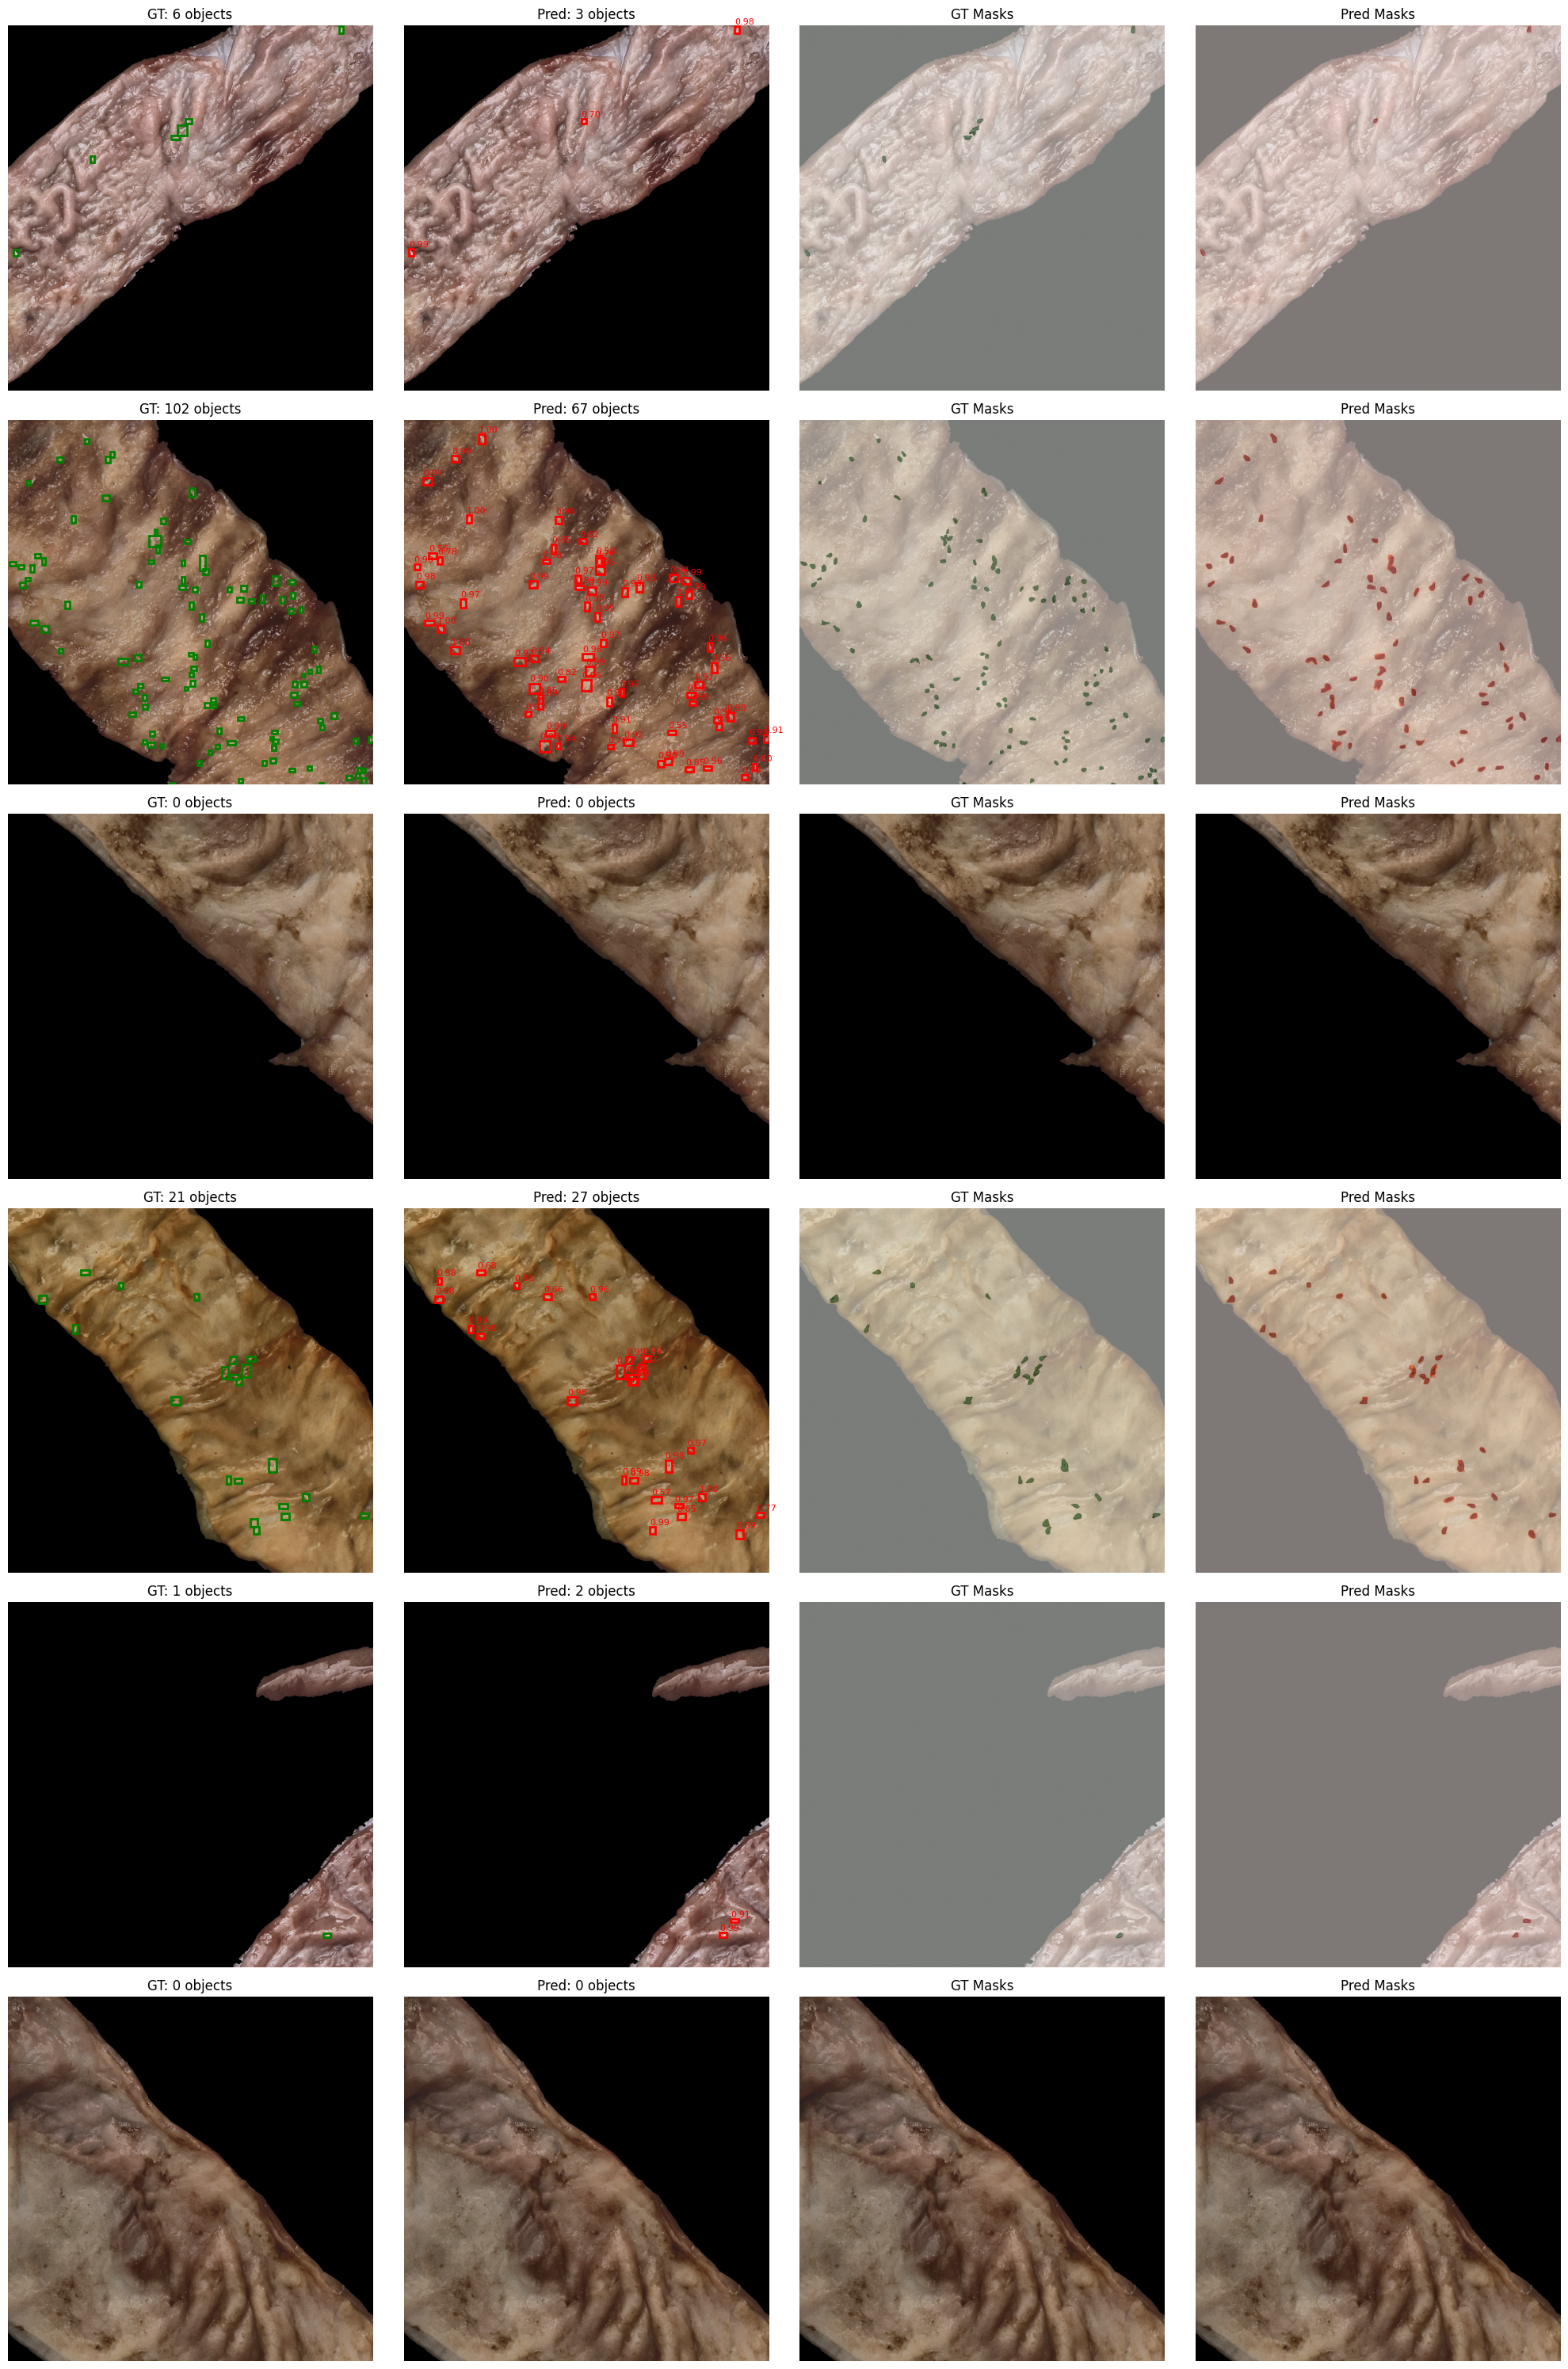

In [ ]:
config = {
    'exp_name': 'MaskRCNN_Baseline',
    'batch_size': 1,
    'num_epochs': 20,
    'learning_rate': 1e-4,
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'freeze_backbone': True,
    'freeze_epochs': 5,
    'grad_clip': 1.0,
    'scheduler': 'cosine',
    'early_stop_patience': 10,
    'save_best_by': 'f1',
    'score_threshold': 0.5,
    'use_high_recall_model': False,
}

history, trainer = train_maskrcnn(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    config=config,
    checkpoint_dir='checkpoints'
)

print("\nEvaluating on test set...")
test_metrics = evaluate_on_test(
    trainer,
    test_dataset,
    score_threshold=config['score_threshold']
)

print("\nVisualizing predictions...")
visualize_predictions(
    trainer,
    test_dataset,
    num_samples=6,
    score_threshold=config['score_threshold']
)

### Experiment 2

Using STANDARD model configuration
Trainable parameters: 45,655,067

Starting training: MaskRCNN_LowLR
Save best by: F1
Train: 250, Val: 43



Epoch 1/25 [Train]: 100%|██████████| 125/125 [00:51<00:00,  2.41it/s, loss=0.6287]



Epoch 1/25 | LR: 5.00e-05
  Train Loss: 1.1077
  Val Loss: 0.6185 | F1: 0.4406 | IoU: 0.7796
  Precision: 0.3283 | Recall: 0.6699
  TP: 280 | FP: 573 | FN: 138
  New best model (F1: 0.4406) ***


Epoch 2/25 [Train]: 100%|██████████| 125/125 [00:54<00:00,  2.27it/s, loss=1.1216]



Epoch 2/25 | LR: 4.98e-05
  Train Loss: 0.7761
  Val Loss: 0.5617 | F1: 0.4928 | IoU: 0.8008
  Precision: 0.3828 | Recall: 0.6914
  TP: 289 | FP: 466 | FN: 129
  New best model (F1: 0.4928) ***


...


Epoch 24/25 | LR: 1.77e-06
  Train Loss: 0.5826
  Val Loss: 0.5571 | F1: 0.5298 | IoU: 0.8147
  Precision: 0.4143 | Recall: 0.7344
  TP: 307 | FP: 434 | FN: 111
  No improvement (7/12)


Epoch 25/25 [Train]: 100%|██████████| 125/125 [00:52<00:00,  2.39it/s, loss=0.5079]



Epoch 25/25 | LR: 1.19e-06
  Train Loss: 0.5774
  Val Loss: 0.5543 | F1: 0.5266 | IoU: 0.8204
  Precision: 0.4143 | Recall: 0.7225
  TP: 302 | FP: 427 | FN: 116
  No improvement (8/12)
Loaded checkpoint from checkpoints/MaskRCNN_LowLR/best_model.pth

Evaluating on test set...


Testing: 100%|██████████| 42/42 [00:08<00:00,  5.16it/s]



TEST RESULTS (threshold=0.5)
Precision: 0.6733
Recall:    0.6401
F1 Score:  0.6562
Mask IoU:  0.8009
TP: 441 | FP: 214 | FN: 248

Visualizing predictions...


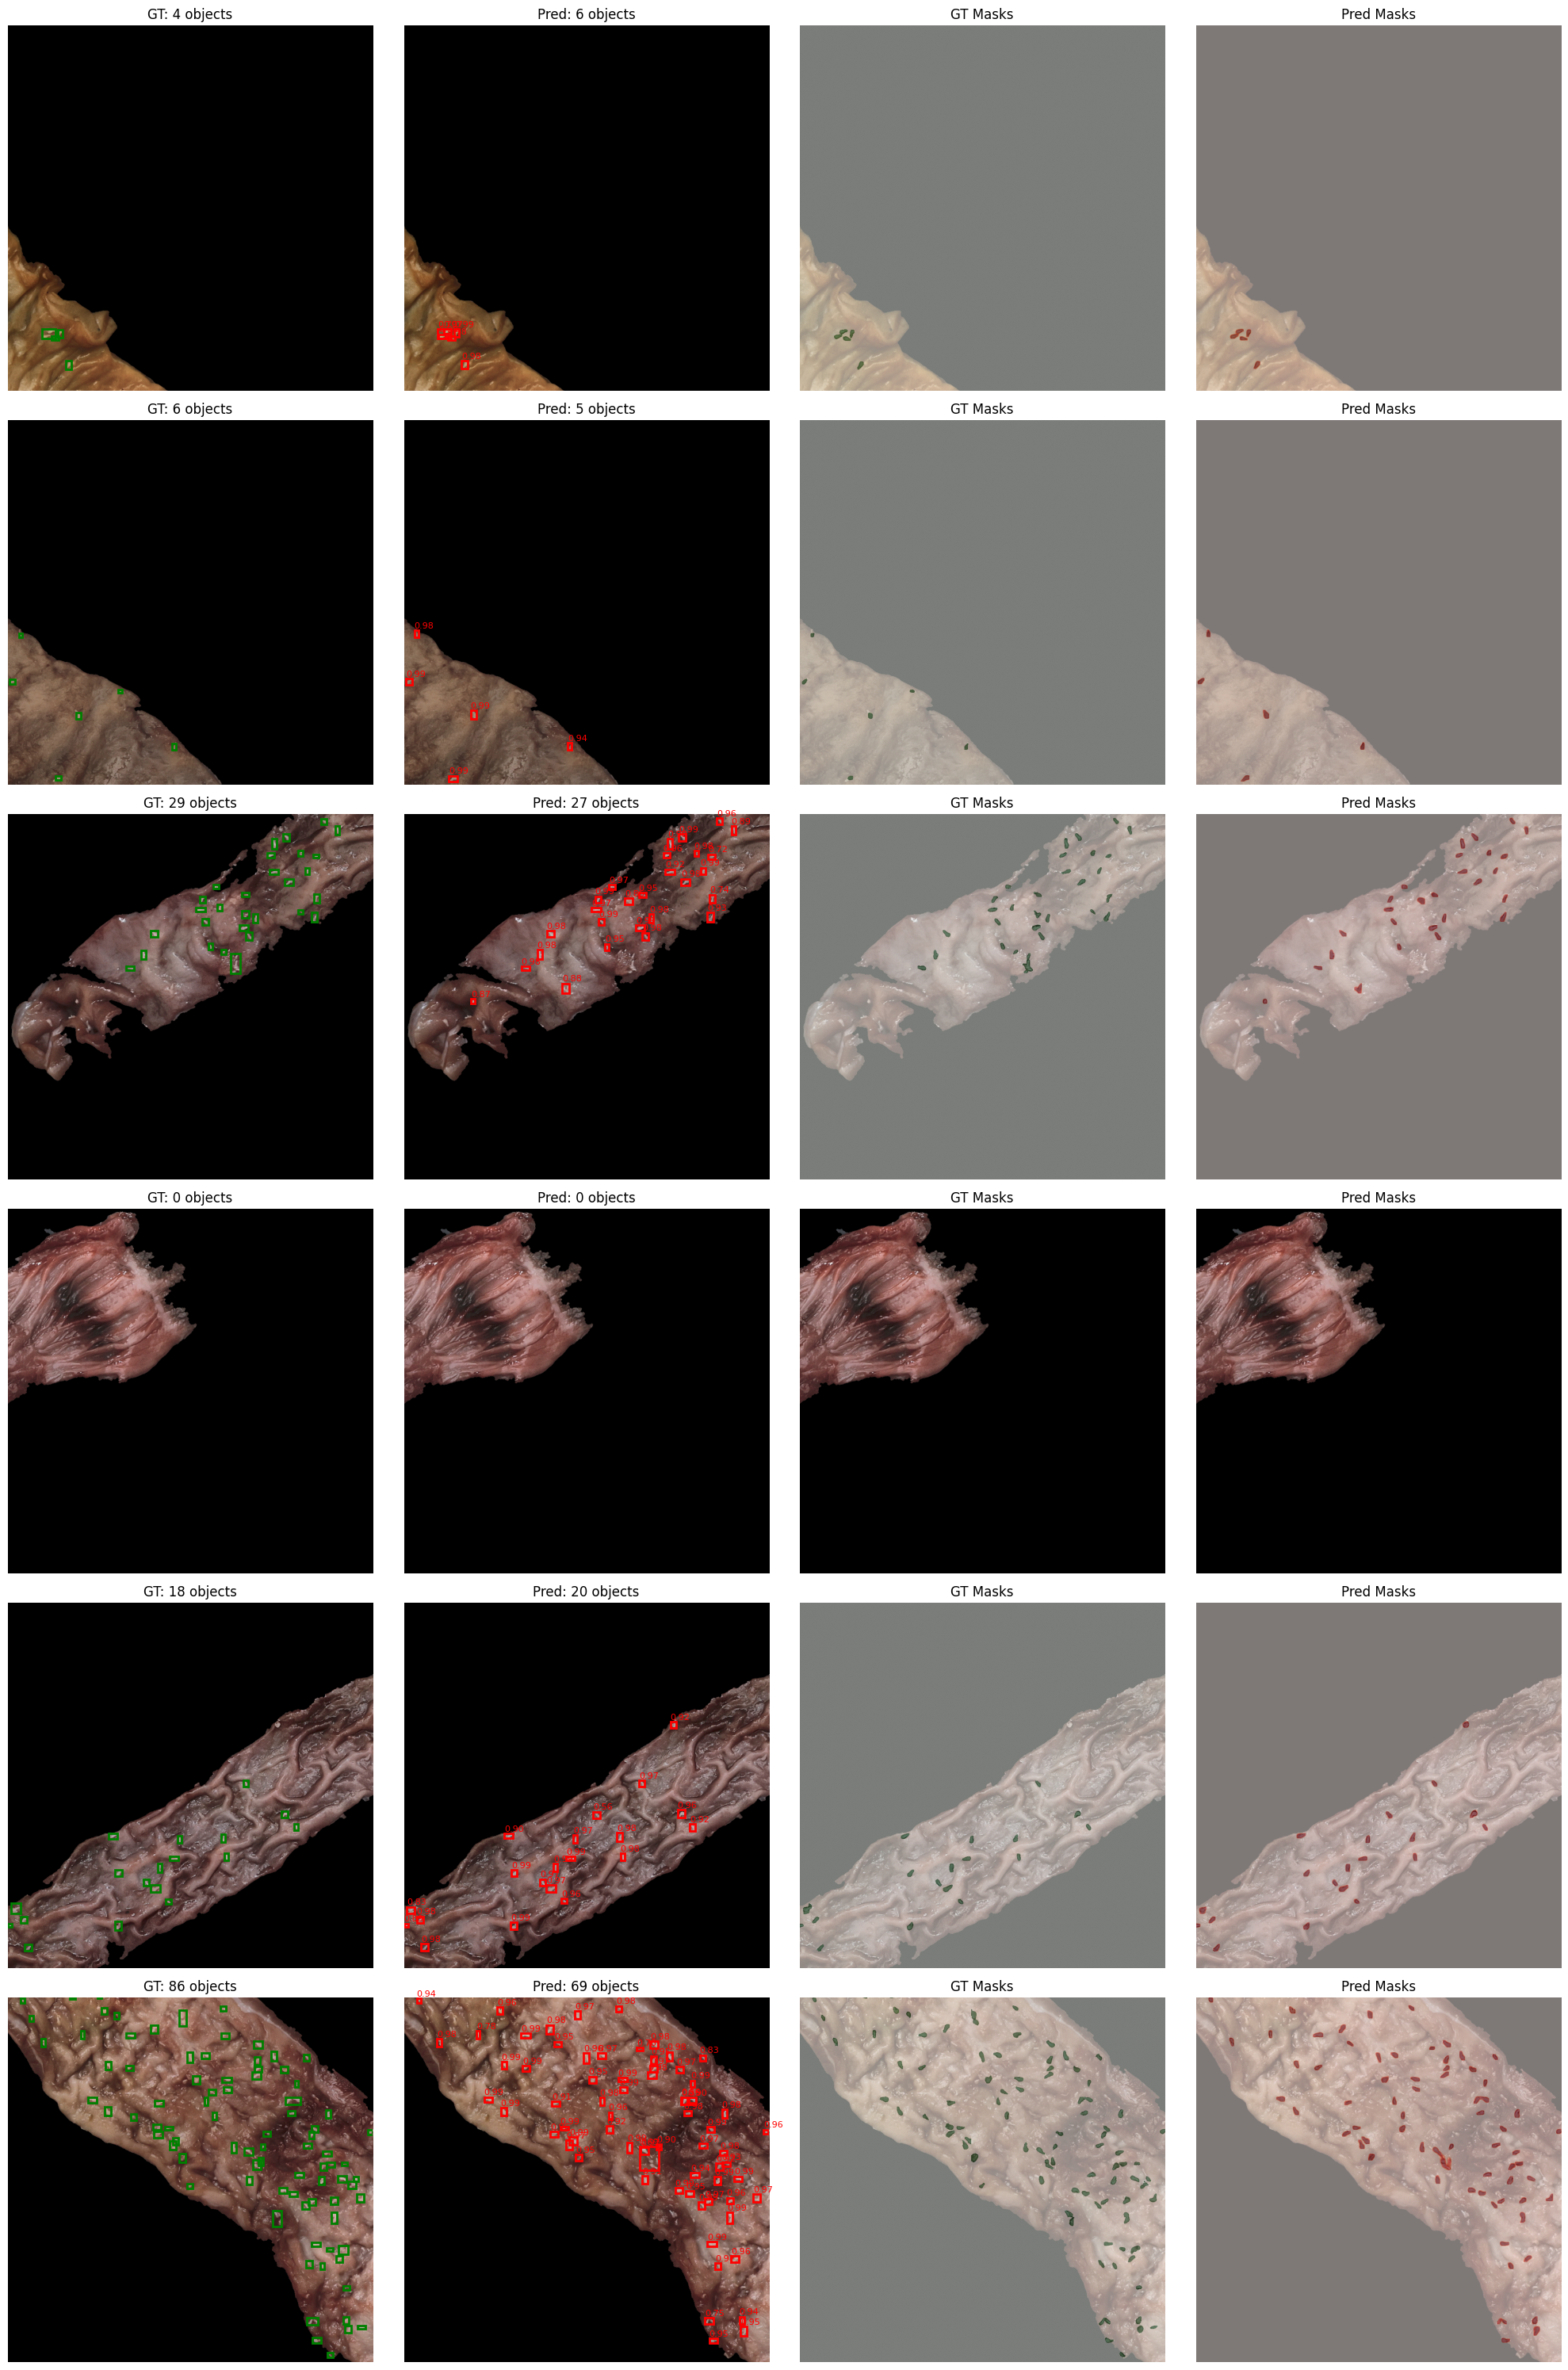

In [ ]:
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_V2_Weights

config = {
    'exp_name': 'MaskRCNN_LowLR',
    'batch_size': 2,
    'num_epochs': 25,
    'learning_rate': 5e-5,  # Lower LR
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'freeze_backbone': False,  # Train full model
    'freeze_epochs': 0,
    'grad_clip': 1.0,
    'scheduler': 'cosine',
    'early_stop_patience': 12,
    'save_best_by': 'f1',
    'score_threshold': 0.5,
    'use_high_recall_model': False,
}
history, trainer = train_maskrcnn(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    config=config,
    checkpoint_dir='checkpoints'
)

print("\nEvaluating on test set...")
test_metrics = evaluate_on_test(
    trainer,
    test_dataset,
    score_threshold=config['score_threshold']
)

print("\nVisualizing predictions...")
visualize_predictions(
    trainer,
    test_dataset,
    num_samples=6,
    score_threshold=config['score_threshold']
)